In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from  sklearn.ensemble import IsolationForest

from sklearn.model_selection import GridSearchCV
import re
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score
from sklearn.feature_selection import SelectKBest, f_classif

data = pd.read_excel('Draft_Campaign.xls')

data.head()

,год поступления,ФИО,Место рождения,Дата рождения,Тип вступительных испытаний (по физлицу),Предмет1,Предмет2,Предмет3,Предмет4,Предмет5,Предмет6,Предмет7,Предмет8,Предмет9,Предмет10,Зачислен,Есть договор утвержден,Документ об образовании.Кем выдан предыдущий документ об образовании,Документ об образовании.Серия диплома,Документ об образовании.Год выдачи
0,2025,Галкиэк Юлия Владимирфээк,"РОССИЯ, Красноярский край, р-н Эвенкийский, п ...",18.03.1979,*,83.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,ДВС,NaN
1,2025,Бегишева Ольга Валерьевэк,"Красноярский край, Уярский р-н, Уяр г",13.09.1990,*,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,90БА,NaN
2,2025,Паля Всеволод Дмитриевич,Красноярск-26,03.10.1994,*,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,аа,NaN
3,2025,Супрун Валероф Александрфэич,Ачинск,31.08.1987,*,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,102424,NaN
4,2025,Цыбикжаьюва Анфыджэк джйцлаевэк,"РОССИЯ, Республика Бурятия, р-н Джидинский, с ...",08.08.1975,*,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,ВСВ0207322,NaN


Часть 1: Анализ и очистка данных

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1766 entries, 0 to 1765
Data columns (total 20 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   год поступления                                                       1766 non-null   int64  
 1   ФИО                                                                   1766 non-null   object 
 2   Место рождения                                                        1760 non-null   object 
 3   Дата рождения                                                         1766 non-null   object 
 4   Тип вступительных испытаний (по физлицу)                              1765 non-null   object 
 5   Предмет1                                                              1710 non-null   float64
 6   Предмет2                                                              1346 non-null   float64
 7

1.1. Преобразуем даты рождения в формат Pd

In [3]:
data['Дата рождения'] = pd.to_datetime(data['Дата рождения'])
data.head()

,год поступления,ФИО,Место рождения,Дата рождения,Тип вступительных испытаний (по физлицу),Предмет1,Предмет2,Предмет3,Предмет4,Предмет5,Предмет6,Предмет7,Предмет8,Предмет9,Предмет10,Зачислен,Есть договор утвержден,Документ об образовании.Кем выдан предыдущий документ об образовании,Документ об образовании.Серия диплома,Документ об образовании.Год выдачи
0,2025,Галкиэк Юлия Владимирфээк,"РОССИЯ, Красноярский край, р-н Эвенкийский, п ...",1979-03-18,*,83.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,ДВС,NaN
1,2025,Бегишева Ольга Валерьевэк,"Красноярский край, Уярский р-н, Уяр г",1990-09-13,*,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,90БА,NaN
2,2025,Паля Всеволод Дмитриевич,Красноярск-26,1994-10-03,*,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,аа,NaN
3,2025,Супрун Валероф Александрфэич,Ачинск,1987-08-31,*,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,102424,NaN
4,2025,Цыбикжаьюва Анфыджэк джйцлаевэк,"РОССИЯ, Республика Бурятия, р-н Джидинский, с ...",1975-08-08,*,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,ВСВ0207322,NaN


In [4]:
data.describe(include=object)

,ФИО,Место рождения,Тип вступительных испытаний (по физлицу),Зачислен,Есть договор утвержден,Документ об образовании.Серия диплома,Документ об образовании.Год выдачи
count,1766,1760,1765,1766,1766,1039,82
unique,1581,747,3,1,2,169,76
top,Дивиэк Аэкстасия Александрфээк,"РОССИЯ, Красноярский край, г Красноярск",*,Да,Да,102424,02424002706195
freq,3,330,846,1766,1298,191,2


In [5]:
print('Количество пропущенных значений составляет', data.isna().sum().sum())


Количество пропущенных значений составляет 17478


In [6]:
print('Количество полностью дублирующихся записей', data.duplicated().sum())
data.drop_duplicates(inplace=True)
print('Количество строк после удаления дубликтов', data.shape[0])

Количество полностью дублирующихся записей 3
Количество строк после удаления дубликтов 1763


In [7]:
print('Количество пропущенных значений составляет', data.isna().sum().sum())
data.dropna
print('Количество строк после удаления пропусков', data.shape[0])

Количество пропущенных значений составляет 17450
Количество строк после удаления пропусков 1763


In [8]:
data['Место рождения'].value_counts()

,count
Место рождения,
"РОССИЯ, Красноярский край, г Красноярск",329
г. Красноярск,51
г.Красноярск,49
Красноярск,44
"Красноярский край, г Красноярск",43
...,...
г. Иркутск,1
"РОССИЯ, Красноярский край, р-н Казачинский, с Галанино",1
гор. Шарыпово Красноярский край Россия,1


1.2. Обработаем пропуски в данных

In [9]:
# обработаем пропуски в категориальных признаках: "Место рождения", заменив их на модальные значения
m_bp = data['Место рождения'].mode()[0]


data['Место рождения'] = data['Место рождения'].apply(lambda x: m_bp if pd.isna(x) else x)


In [10]:
# обработаем пропуски в категориальных признаках: "Тип вступительных испытаний (по физлицу)", заменив их на модальные значения
m_te = data['Тип вступительных испытаний (по физлицу)'].mode()[0]


data['Тип вступительных испытаний (по физлицу)'] = data['Тип вступительных испытаний (по физлицу)'].apply(lambda x: m_te if pd.isna(x) else x)

In [11]:
data.head()

,год поступления,ФИО,Место рождения,Дата рождения,Тип вступительных испытаний (по физлицу),Предмет1,Предмет2,Предмет3,Предмет4,Предмет5,Предмет6,Предмет7,Предмет8,Предмет9,Предмет10,Зачислен,Есть договор утвержден,Документ об образовании.Кем выдан предыдущий документ об образовании,Документ об образовании.Серия диплома,Документ об образовании.Год выдачи
0,2025,Галкиэк Юлия Владимирфээк,"РОССИЯ, Красноярский край, р-н Эвенкийский, п ...",1979-03-18,*,83.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,ДВС,NaN
1,2025,Бегишева Ольга Валерьевэк,"Красноярский край, Уярский р-н, Уяр г",1990-09-13,*,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,90БА,NaN
2,2025,Паля Всеволод Дмитриевич,Красноярск-26,1994-10-03,*,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,аа,NaN
3,2025,Супрун Валероф Александрфэич,Ачинск,1987-08-31,*,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,102424,NaN
4,2025,Цыбикжаьюва Анфыджэк джйцлаевэк,"РОССИЯ, Республика Бурятия, р-н Джидинский, с ...",1975-08-08,*,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,ВСВ0207322,NaN


1.3. Удаляем столбцы, не несущие полезной информации

In [12]:
#удалим неинформативные столбцы
data.drop(labels=['Предмет4','Предмет5','Предмет6','Предмет7','Предмет8','Предмет9','Предмет10','Документ об образовании.Кем выдан предыдущий документ об образовании','Документ об образовании.Серия диплома','Документ об образовании.Год выдачи',], axis=1, inplace=True)


In [13]:
data.head()

,год поступления,ФИО,Место рождения,Дата рождения,Тип вступительных испытаний (по физлицу),Предмет1,Предмет2,Предмет3,Зачислен,Есть договор утвержден
0,2025,Галкиэк Юлия Владимирфээк,"РОССИЯ, Красноярский край, р-н Эвенкийский, п ...",1979-03-18,*,83.0,NaN,NaN,Да,Да
1,2025,Бегишева Ольга Валерьевэк,"Красноярский край, Уярский р-н, Уяр г",1990-09-13,*,78.0,NaN,NaN,Да,Да
2,2025,Паля Всеволод Дмитриевич,Красноярск-26,1994-10-03,*,82.0,NaN,NaN,Да,Да
3,2025,Супрун Валероф Александрфэич,Ачинск,1987-08-31,*,82.0,NaN,NaN,Да,Да
4,2025,Цыбикжаьюва Анфыджэк джйцлаевэк,"РОССИЯ, Республика Бурятия, р-н Джидинский, с ...",1975-08-08,*,82.0,NaN,NaN,Да,Да


1.2. Генерация признаков

In [14]:
#начнем генерацию признаков. 1. Отделим студентов, поступающих на бакалавриат/специалитет (они сдают только 3 предмета) от студентов , поступающих в магистратуру (они сдают только 1 предмет)
data['is_bachelor'] = data['Предмет2'].apply(lambda x: 1 if x > 0 else 0)

In [15]:
data['is_master'] = data['is_master'] = data.apply(lambda row: 1 if pd.isna(row['Предмет2']) and row['Предмет1'] > 0 else 0, axis=1)

In [16]:
data.head()

,год поступления,ФИО,Место рождения,Дата рождения,Тип вступительных испытаний (по физлицу),Предмет1,Предмет2,Предмет3,Зачислен,Есть договор утвержден,is_bachelor,is_master
0,2025,Галкиэк Юлия Владимирфээк,"РОССИЯ, Красноярский край, р-н Эвенкийский, п ...",1979-03-18,*,83.0,NaN,NaN,Да,Да,0,1
1,2025,Бегишева Ольга Валерьевэк,"Красноярский край, Уярский р-н, Уяр г",1990-09-13,*,78.0,NaN,NaN,Да,Да,0,1
2,2025,Паля Всеволод Дмитриевич,Красноярск-26,1994-10-03,*,82.0,NaN,NaN,Да,Да,0,1
3,2025,Супрун Валероф Александрфэич,Ачинск,1987-08-31,*,82.0,NaN,NaN,Да,Да,0,1
4,2025,Цыбикжаьюва Анфыджэк джйцлаевэк,"РОССИЯ, Республика Бурятия, р-н Джидинский, с ...",1975-08-08,*,82.0,NaN,NaN,Да,Да,0,1


In [17]:
data['year'] = data['Дата рождения'].dt.year
data['month'] = data['Дата рождения'].dt.month
data.head()

,год поступления,ФИО,Место рождения,Дата рождения,Тип вступительных испытаний (по физлицу),Предмет1,Предмет2,Предмет3,Зачислен,Есть договор утвержден,is_bachelor,is_master,year,month
0,2025,Галкиэк Юлия Владимирфээк,"РОССИЯ, Красноярский край, р-н Эвенкийский, п ...",1979-03-18,*,83.0,NaN,NaN,Да,Да,0,1,1979,3
1,2025,Бегишева Ольга Валерьевэк,"Красноярский край, Уярский р-н, Уяр г",1990-09-13,*,78.0,NaN,NaN,Да,Да,0,1,1990,9
2,2025,Паля Всеволод Дмитриевич,Красноярск-26,1994-10-03,*,82.0,NaN,NaN,Да,Да,0,1,1994,10
3,2025,Супрун Валероф Александрфэич,Ачинск,1987-08-31,*,82.0,NaN,NaN,Да,Да,0,1,1987,8
4,2025,Цыбикжаьюва Анфыджэк джйцлаевэк,"РОССИЯ, Республика Бурятия, р-н Джидинский, с ...",1975-08-08,*,82.0,NaN,NaN,Да,Да,0,1,1975,8


In [18]:
#далее, выделим в качестве столбца возраст на момент подачи заявления
data['abitur_age'] = data['год поступления'] - data['year']
data.head()

,год поступления,ФИО,Место рождения,Дата рождения,Тип вступительных испытаний (по физлицу),Предмет1,Предмет2,Предмет3,Зачислен,Есть договор утвержден,is_bachelor,is_master,year,month,abitur_age
0,2025,Галкиэк Юлия Владимирфээк,"РОССИЯ, Красноярский край, р-н Эвенкийский, п ...",1979-03-18,*,83.0,NaN,NaN,Да,Да,0,1,1979,3,46
1,2025,Бегишева Ольга Валерьевэк,"Красноярский край, Уярский р-н, Уяр г",1990-09-13,*,78.0,NaN,NaN,Да,Да,0,1,1990,9,35
2,2025,Паля Всеволод Дмитриевич,Красноярск-26,1994-10-03,*,82.0,NaN,NaN,Да,Да,0,1,1994,10,31
3,2025,Супрун Валероф Александрфэич,Ачинск,1987-08-31,*,82.0,NaN,NaN,Да,Да,0,1,1987,8,38
4,2025,Цыбикжаьюва Анфыджэк джйцлаевэк,"РОССИЯ, Республика Бурятия, р-н Джидинский, с ...",1975-08-08,*,82.0,NaN,NaN,Да,Да,0,1,1975,8,50


In [19]:
#Далее - извлечем данные из строки Место рождения. Для начала - выделим тех, кто из Красноярского края

regex_krasnoyarsk = '[Кк][Рр][Аа][Сс][Нн][Оо][Яя][Рр][Сс][Кк]'
data['is_Krasnoyarsk'] = data['Место рождения'].str.findall(regex_krasnoyarsk).str.get(0)


In [20]:
#Затем - выделим ключевые соседние регионы (Хакасия, Тыва, иркутская область)
regex_khakas = '[Хх][Аа][Кк][Аа][Сс]'
data['is_khakas'] = data['Место рождения'].str.findall(regex_khakas).str.get(0)

regex_tyva = '[Тт][УуЫы][Вв][Аа]'
data['is_tyva'] = data['Место рождения'].str.findall(regex_tyva).str.get(0)

regex_irkut = '[Ии][Рр][Кк][Уу][Тт][Сс][Кк]'
data['is_irkut'] = data['Место рождения'].str.findall(regex_irkut).str.get(0)

In [21]:
#Отдельно отметим тех, кто приезжает из Средней Азии
regex_midas = '[Сс][Тт][Аа][Нн]'
data['is_midas'] = data['Место рождения'].str.findall(regex_midas).str.get(0)

In [22]:
data.head()

,год поступления,ФИО,Место рождения,Дата рождения,Тип вступительных испытаний (по физлицу),Предмет1,Предмет2,Предмет3,Зачислен,Есть договор утвержден,is_bachelor,is_master,year,month,abitur_age,is_Krasnoyarsk,is_khakas,is_tyva,is_irkut,is_midas
0,2025,Галкиэк Юлия Владимирфээк,"РОССИЯ, Красноярский край, р-н Эвенкийский, п ...",1979-03-18,*,83.0,NaN,NaN,Да,Да,0,1,1979,3,46,Красноярск,NaN,NaN,NaN,NaN
1,2025,Бегишева Ольга Валерьевэк,"Красноярский край, Уярский р-н, Уяр г",1990-09-13,*,78.0,NaN,NaN,Да,Да,0,1,1990,9,35,Красноярск,NaN,NaN,NaN,NaN
2,2025,Паля Всеволод Дмитриевич,Красноярск-26,1994-10-03,*,82.0,NaN,NaN,Да,Да,0,1,1994,10,31,Красноярск,NaN,NaN,NaN,NaN
3,2025,Супрун Валероф Александрфэич,Ачинск,1987-08-31,*,82.0,NaN,NaN,Да,Да,0,1,1987,8,38,NaN,NaN,NaN,NaN,NaN
4,2025,Цыбикжаьюва Анфыджэк джйцлаевэк,"РОССИЯ, Республика Бурятия, р-н Джидинский, с ...",1975-08-08,*,82.0,NaN,NaN,Да,Да,0,1,1975,8,50,NaN,NaN,NaN,NaN,NaN


In [23]:
#Далее, преобразуем получившиеся столбцы в формат Dummies
data['is_Krasnoyarsk'] = data['is_Krasnoyarsk'] = data.apply(lambda row: 0 if pd.isna(row['is_Krasnoyarsk'])  else 1, axis=1)

In [24]:
data['is_khakas'] = data.apply(lambda row: 0 if pd.isna(row['is_khakas'])  else 1, axis=1)
data['is_tyva'] = data.apply(lambda row: 0 if pd.isna(row['is_tyva'])  else 1, axis=1)
data['is_irkut'] = data.apply(lambda row: 0 if pd.isna(row['is_irkut'])  else 1, axis=1)
data['is_midas'] = data.apply(lambda row: 0 if pd.isna(row['is_midas'])  else 1, axis=1)

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1763 entries, 0 to 1765
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   год поступления                           1763 non-null   int64         
 1   ФИО                                       1763 non-null   object        
 2   Место рождения                            1763 non-null   object        
 3   Дата рождения                             1763 non-null   datetime64[ns]
 4   Тип вступительных испытаний (по физлицу)  1763 non-null   object        
 5   Предмет1                                  1707 non-null   float64       
 6   Предмет2                                  1343 non-null   float64       
 7   Предмет3                                  1307 non-null   float64       
 8   Зачислен                                  1763 non-null   object        
 9   Есть договор утвержден             

In [26]:
#все прочие регионы, не относящиеся к 5 вышеупомянутым, выделим в отдельную категорию
data['is_otherreg'] = data['is_Krasnoyarsk'] + data['is_khakas'] + data['is_tyva'] + data['is_irkut'] + data['is_midas']


In [27]:
data['is_otherreg'] = data.apply(lambda row: 0 if row['is_otherreg']>0  else 1, axis=1)

In [28]:
data['Предмет1'] = data.apply(lambda row: 0 if pd.isna(row['Предмет1']) else row['Предмет1'], axis=1)
data['Предмет2'] = data.apply(lambda row: 0 if pd.isna(row['Предмет2']) else row['Предмет2'], axis=1)
data['Предмет3'] = data.apply(lambda row: 0 if pd.isna(row['Предмет3']) else row['Предмет3'], axis=1)

In [29]:
data.head(50)

,год поступления,ФИО,Место рождения,Дата рождения,Тип вступительных испытаний (по физлицу),Предмет1,Предмет2,Предмет3,Зачислен,Есть договор утвержден,...,is_master,year,month,abitur_age,is_Krasnoyarsk,is_khakas,is_tyva,is_irkut,is_midas,is_otherreg
0,2025,Галкиэк Юлия Владимирфээк,"РОССИЯ, Красноярский край, р-н Эвенкийский, п ...",1979-03-18,*,83.0,0.0,0.0,Да,Да,...,1,1979,3,46,1,0,0,0,0,0
1,2025,Бегишева Ольга Валерьевэк,"Красноярский край, Уярский р-н, Уяр г",1990-09-13,*,78.0,0.0,0.0,Да,Да,...,1,1990,9,35,1,0,0,0,0,0
2,2025,Паля Всеволод Дмитриевич,Красноярск-26,1994-10-03,*,82.0,0.0,0.0,Да,Да,...,1,1994,10,31,1,0,0,0,0,0
3,2025,Супрун Валероф Александрфэич,Ачинск,1987-08-31,*,82.0,0.0,0.0,Да,Да,...,1,1987,8,38,0,0,0,0,0,1
4,2025,Цыбикжаьюва Анфыджэк джйцлаевэк,"РОССИЯ, Республика Бурятия, р-н Джидинский, с ...",1975-08-08,*,82.0,0.0,0.0,Да,Да,...,1,1975,8,50,0,0,0,0,0,1
5,2025,Якимфэа Аэкстасия Вячеславфээк,Гор. Красноярск,2002-09-23,*,82.0,0.0,0.0,Да,Да,...,1,2002,9,23,1,0,0,0,0,0
6,2025,Ленская Анэк Владимирфээк,г. Сосновоборск Красноярский край,2001-12-04,*,77.0,0.0,0.0,Да,Да,...,1,2001,12,24,1,0,0,0,0,0
7,2025,Зичтвьев Валероф Андреевич,Г. НОРИЛЬСК КРАСНОЯРСКИЙ КРАЙ,2003-08-21,Совм.,81.0,0.0,0.0,Да,Да,...,1,2003,8,22,1,0,0,0,0,0
8,2025,Татарджйцв Евгеджй Вадимфэич,гор. Дивногорск Красноярского края,1995-12-18,*,80.0,0.0,0.0,Да,Да,...,1,1995,12,30,1,0,0,0,0,0
9,2025,Казайцва Аэкстасия Дмитриевэк,"Красноярский край, с. Новобирилюссы, бирилюсск...",2004-01-10,Совм.,79.0,0.0,0.0,Да,Да,...,1,2004,1,21,1,0,0,0,0,0


In [30]:
#В качестве следующего признака выделим жителей городских и сельских поселений
# Создаем маску для выделения сельских поселений
regex_selo = '[\s|^|,][CcДд|Пос|ПОС|][\s|.]'
data['is_selo'] = data['Место рождения'].str.findall(regex_selo).str.get(0)

In [31]:
#затем преобразуем получившиеся значения в 1-0
data['is_selo'] = data.apply(lambda row: 0 if pd.isna(row['is_selo'])  else 1, axis=1)

In [32]:
#Все остальные поселения отметим как городские
data['is_gorod'] = data.apply(lambda row: 0 if row['is_selo'] == 1 else 1, axis=1)

In [33]:
#Теперь нам надо выделить в отдельные группы результаты экзаменов.
#Так как, с баллом менее 30 в настоящее время заключать договор на обучение нельзя, выделим группы: <30 баллов и далее с шагом по 10 балов вплоть до 100 максимум
data['test_1_<30'] = data.apply(lambda row: 1 if row['Предмет1'] < 30 else 0, axis=1)

In [34]:
data['test_1_30-40'] = data.apply(lambda row: 1 if (row['Предмет1'] > 31 and row['Предмет1'] < 40) else 0, axis=1)

In [35]:
data['test_1_40-50'] = data.apply(lambda row: 1 if (row['Предмет1'] > 41 and row['Предмет1'] < 50) else 0, axis=1)
data['test_1_50-60'] = data.apply(lambda row: 1 if (row['Предмет1'] > 51 and row['Предмет1'] < 60) else 0, axis=1)
data['test_1_60-70'] = data.apply(lambda row: 1 if (row['Предмет1'] > 61 and row['Предмет1'] < 70) else 0, axis=1)
data['test_1_70-80'] = data.apply(lambda row: 1 if (row['Предмет1'] > 71 and row['Предмет1'] < 80) else 0, axis=1)
data['test_1_81-90'] = data.apply(lambda row: 1 if (row['Предмет1'] > 81 and row['Предмет1'] < 90) else 0, axis=1)
data['test_1_91-100'] = data.apply(lambda row: 1 if (row['Предмет1'] > 91) else 0, axis=1)

In [36]:
data['test_2_<30'] = data.apply(lambda row: 1 if row['Предмет2'] < 30 else 0, axis=1)
data['test_2_30-40'] = data.apply(lambda row: 1 if (row['Предмет2'] > 31 and row['Предмет2'] < 40) else 0, axis=1)
data['test_2_40-50'] = data.apply(lambda row: 1 if (row['Предмет2'] > 41 and row['Предмет2'] < 50) else 0, axis=1)
data['test_2_50-60'] = data.apply(lambda row: 1 if (row['Предмет2'] > 51 and row['Предмет2'] < 60) else 0, axis=1)
data['test_2_60-70'] = data.apply(lambda row: 1 if (row['Предмет2'] > 61 and row['Предмет2'] < 70) else 0, axis=1)
data['test_2_70-80'] = data.apply(lambda row: 1 if (row['Предмет2'] > 71 and row['Предмет2'] < 80) else 0, axis=1)
data['test_2_81-90'] = data.apply(lambda row: 1 if (row['Предмет2'] > 81 and row['Предмет2'] < 90) else 0, axis=1)
data['test_2_91-100'] = data.apply(lambda row: 1 if (row['Предмет2'] > 91) else 0, axis=1)

In [37]:
data['test_3_<30'] = data.apply(lambda row: 1 if row['Предмет3'] < 30 else 0, axis=1)
data['test_3_30-40'] = data.apply(lambda row: 1 if (row['Предмет3'] > 31 and row['Предмет3'] < 40) else 0, axis=1)
data['test_3_40-50'] = data.apply(lambda row: 1 if (row['Предмет3'] > 41 and row['Предмет3'] < 50) else 0, axis=1)
data['test_3_50-60'] = data.apply(lambda row: 1 if (row['Предмет3'] > 51 and row['Предмет3'] < 60) else 0, axis=1)
data['test_3_60-70'] = data.apply(lambda row: 1 if (row['Предмет3'] > 61 and row['Предмет3'] < 70) else 0, axis=1)
data['test_3_70-80'] = data.apply(lambda row: 1 if (row['Предмет3'] > 71 and row['Предмет3'] < 80) else 0, axis=1)
data['test_3_81-90'] = data.apply(lambda row: 1 if (row['Предмет3'] > 81 and row['Предмет3'] < 90) else 0, axis=1)
data['test_3_91-100'] = data.apply(lambda row: 1 if (row['Предмет3'] > 91) else 0, axis=1)

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1763 entries, 0 to 1765
Data columns (total 47 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   год поступления                           1763 non-null   int64         
 1   ФИО                                       1763 non-null   object        
 2   Место рождения                            1763 non-null   object        
 3   Дата рождения                             1763 non-null   datetime64[ns]
 4   Тип вступительных испытаний (по физлицу)  1763 non-null   object        
 5   Предмет1                                  1763 non-null   float64       
 6   Предмет2                                  1763 non-null   float64       
 7   Предмет3                                  1763 non-null   float64       
 8   Зачислен                                  1763 non-null   object        
 9   Есть договор утвержден             

In [39]:
#Наконец - выделим целевой показатель. В данном случае - это столбец "Есть договор утвержден"
data['result'] = data.apply(lambda row: 1 if row['Есть договор утвержден'] == "Да" else 0, axis=1)

По итогам, получаем 46 признаков (нулевые значения в столбце отсутствуют)

2.1. Визуализация данных

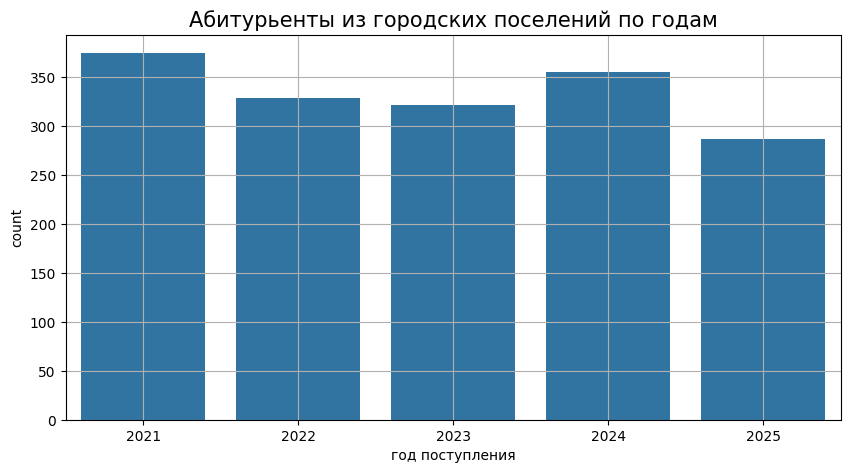

In [40]:
#Теперь - проведем визуализацию результатов

data_from_city = data.groupby('год поступления')['is_gorod'].sum().sort_values()
data_from_city = pd.DataFrame({'год поступления': data_from_city.index, 'count': data_from_city.values})

fig, axes = plt.subplots(figsize=(10, 5))
barplot = sns.barplot(
    data=data_from_city,
    x='год поступления',
    y='count',
    orient='v',
    ci=None)

barplot.set_title('Абитурьенты из городских поселений по годам', fontsize=15);
barplot.grid()

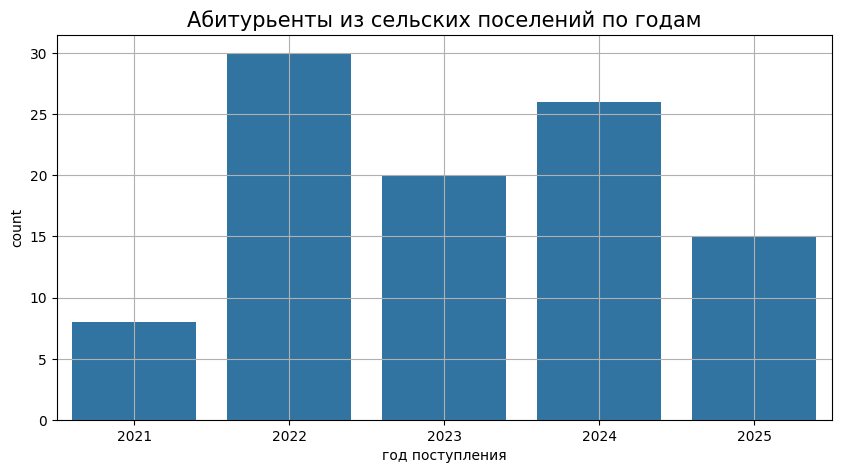

In [41]:
data_from_country = data.groupby('год поступления')['is_selo'].sum().sort_values()
data_from_country = pd.DataFrame({'год поступления': data_from_country.index, 'count': data_from_country.values})

fig, axes = plt.subplots(figsize=(10, 5))
barplot = sns.barplot(
    data=data_from_country,
    x='год поступления',
    y='count',
    orient='v',
    ci=None)

barplot.set_title('Абитурьенты из сельских поселений по годам', fontsize=15);
barplot.grid()

Можно видеть, что численность, поступающих из городов и пгт существенно превосходит численность абитурьентов из сельских территорий. Однако, также стоит отметить, что важна не столько численность абитурьентов в целом, но и число тех из них, кто заключает договор на учебу

<Axes: xlabel='result'>

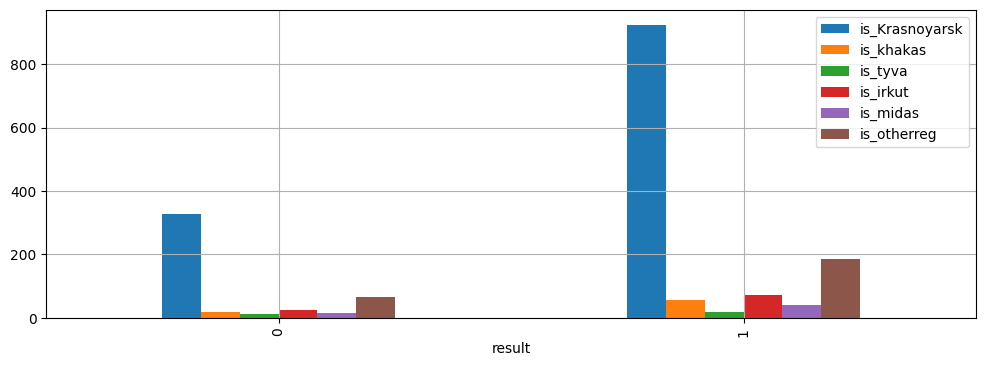

In [67]:
#Теперь, создадим гистограмму по регионам поступающих
data_grouped_region = data.groupby('result')[['is_Krasnoyarsk', 'is_khakas', 'is_tyva', 'is_irkut', 'is_midas', 'is_otherreg']].sum()
data_grouped_region.plot(kind='bar', grid=True, figsize=(12, 4))

<Axes: xlabel='is_Krasnoyarsk', ylabel='count'>

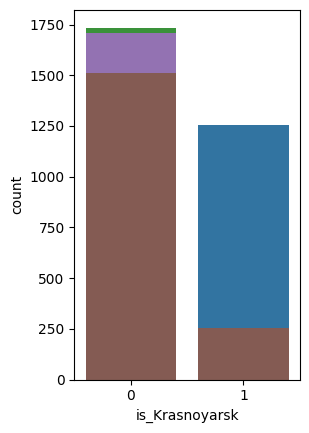

In [43]:
plt.subplot(1, 2, 1)
sns.countplot(x='is_Krasnoyarsk', data=data)
plt.subplot(1, 2, 1)
sns.countplot(x='is_khakas', data=data)
plt.subplot(1, 2, 1)
sns.countplot(x='is_tyva', data=data)
plt.subplot(1, 2, 1)
sns.countplot(x='is_irkut', data=data)
plt.subplot(1, 2, 1)
sns.countplot(x='is_midas', data=data)
plt.subplot(1, 2, 1)
sns.countplot(x='is_otherreg', data=data)


Text(0.5, 1.0, 'Договор утвержден в зависимости от экзамена 3')

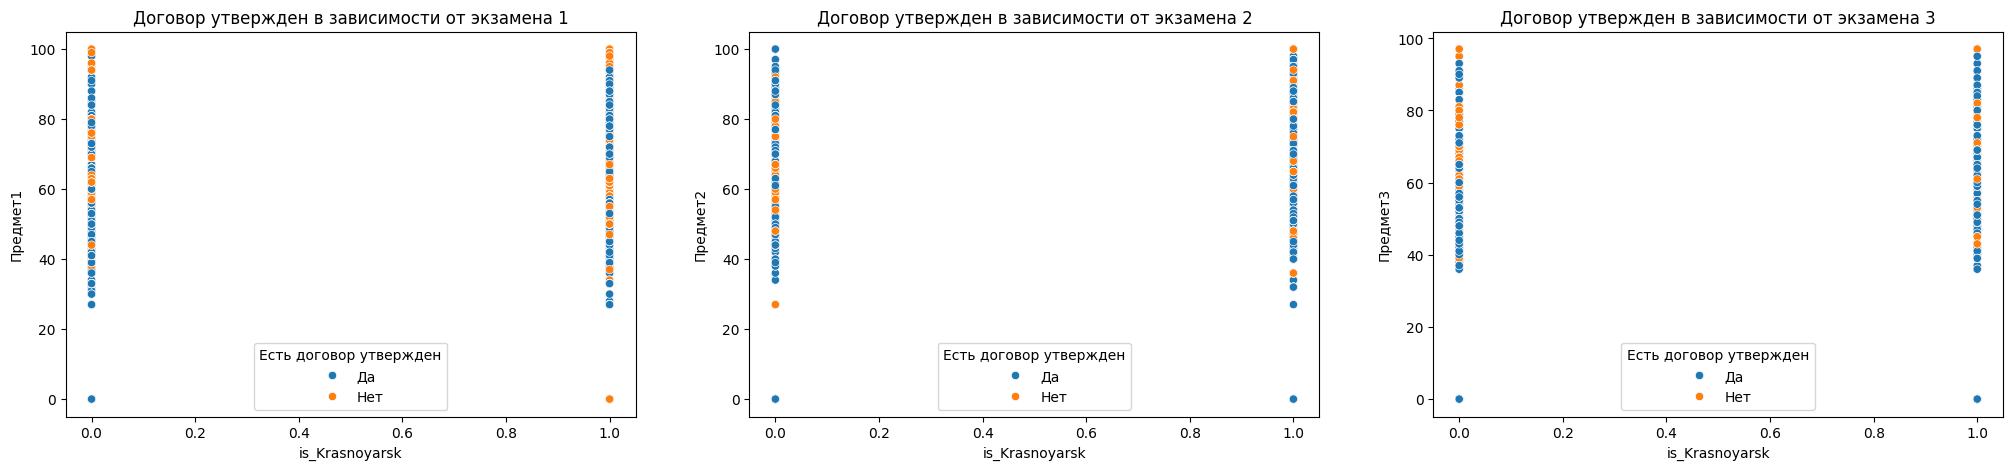

In [44]:
#Далее, посмотрим на зависимость положительного решение от среднего балла по экзаменам

fig, axes = plt.subplots(1, 3, figsize=(25, 5))

sns.scatterplot(x="is_Krasnoyarsk", y="Предмет1", hue="Есть договор утвержден", data=data, ax=axes[0])
axes[0].set_title("Договор утвержден в зависимости от экзамена 1")

sns.scatterplot(x="is_Krasnoyarsk", y="Предмет2", hue="Есть договор утвержден", data=data, ax=axes[1])
axes[1].set_title("Договор утвержден в зависимости от экзамена 2")

sns.scatterplot(x="is_Krasnoyarsk", y="Предмет3", hue="Есть договор утвержден", data=data, ax=axes[2])
axes[2].set_title("Договор утвержден в зависимости от экзамена 3")

Можно сделать вывод о том, что в первую очередь договор на обучение заключают либо те, кто набрал по предмету 1 минимальный проходной балл, либо те, кто набрал баллы в диапазоне 65-85 из 100. Причем доля из тех, кто поступает из-за пределов Красноярского края выше, чем в самом регионе. По предмету 2, напротив, лица, поступающие не из Красноярского края с максимальным баллом, чаще всего договор заключают

Text(0.5, 1.0, 'Договор утвержден в зависимости от экзамена 3')

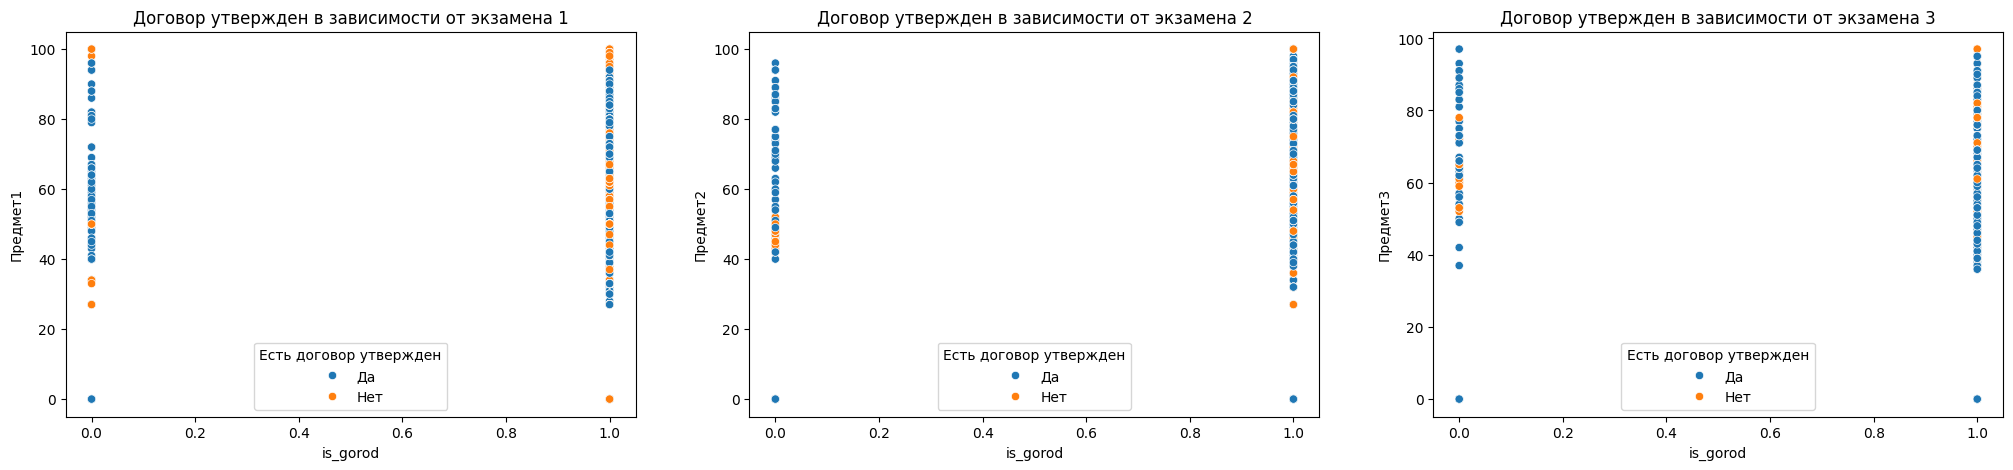

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5))

sns.scatterplot(x="is_gorod", y="Предмет1", hue="Есть договор утвержден", data=data, ax=axes[0])
axes[0].set_title("Договор утвержден в зависимости от экзамена 1")

sns.scatterplot(x="is_gorod", y="Предмет2", hue="Есть договор утвержден", data=data, ax=axes[1])
axes[1].set_title("Договор утвержден в зависимости от экзамена 2")

sns.scatterplot(x="is_gorod", y="Предмет3", hue="Есть договор утвержден", data=data, ax=axes[2])
axes[2].set_title("Договор утвержден в зависимости от экзамена 3")

На первый взгляд, кажется что городские абитурьенты более склонны отказываться от заключения договора при успешном прохождении экзамена. Однако, это может быть вызвано их большим числом в абсолюте.

3.1. Регрессионный анализ

In [46]:
#Удяляем лишние столбцы
data2 = data.drop(['год поступления', 'ФИО', 'Место рождения','Дата рождения','Тип вступительных испытаний (по физлицу)','Зачислен','Есть договор утвержден','Предмет1','Предмет2','Предмет3'], axis=1)

In [47]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1763 entries, 0 to 1765
Data columns (total 38 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   is_bachelor     1763 non-null   int64
 1   is_master       1763 non-null   int64
 2   year            1763 non-null   int32
 3   month           1763 non-null   int32
 4   abitur_age      1763 non-null   int64
 5   is_Krasnoyarsk  1763 non-null   int64
 6   is_khakas       1763 non-null   int64
 7   is_tyva         1763 non-null   int64
 8   is_irkut        1763 non-null   int64
 9   is_midas        1763 non-null   int64
 10  is_otherreg     1763 non-null   int64
 11  is_selo         1763 non-null   int64
 12  is_gorod        1763 non-null   int64
 13  test_1_<30      1763 non-null   int64
 14  test_1_30-40    1763 non-null   int64
 15  test_1_40-50    1763 non-null   int64
 16  test_1_50-60    1763 non-null   int64
 17  test_1_60-70    1763 non-null   int64
 18  test_1_70-80    1763 non-null   i

In [48]:
data2.value_counts()

is_bachelor  is_master  year  month  abitur_age  is_Krasnoyarsk  is_khakas  is_tyva  is_irkut  is_midas  is_otherreg  is_selo  is_gorod  test_1_<30  test_1_30-40  test_1_40-50  test_1_50-60  test_1_60-70  test_1_70-80  test_1_81-90  test_1_91-100  test_2_<30  test_2_30-40  test_2_40-50  test_2_50-60  test_2_60-70  test_2_70-80  test_2_81-90  test_2_91-100  test_3_<30  test_3_30-40  test_3_40-50  test_3_50-60  test_3_60-70  test_3_70-80  test_3_81-90  test_3_91-100  result
0            1          2003  4      22          1               0          0        0         0         0            0        1         0           0             0             0             0             0             0             1              1           0             0             0             0             0             0             0              1           0             0             0             0             0             0             0              0         4
                              5      22          1               0          0        0         0         0            0        1         0           0             0             0             0             0             1             0              1           0             0             0             0             0             0             0              1           0             0             0             0             0             0             0              1         3
                        2000  10     22          1               0          0        0         0         0            0        1         0           0             0             0             0             0             0             1              1           0             0             0             0             0             0             0              1           0             0             0             0             0             0             0              1         3
                        2002  7      22          1               0          0        0         0         0            0        1         0           0             0             0             0             0             0             0              1           0             0             0             0             0             0             0              1           0             0             0             0             0             0             0              1         3
1            0          2003  9      19          1               0          0        0         0         0            0        1         0           0             0             1             0             0             0             0              0           0             0             0             0             1             0             0              0           0             0             0             0             0             1             0              1         2
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               ..
                        1999  7      23          1               0          0        0         0         0            0        1         0           0             0             0             0             0             0             0              0           0             0             0             0             0             0             0              0           0             0             1             0             0             0             0              1         1
                                                 0               0          0        0         1         0            0        1         0           

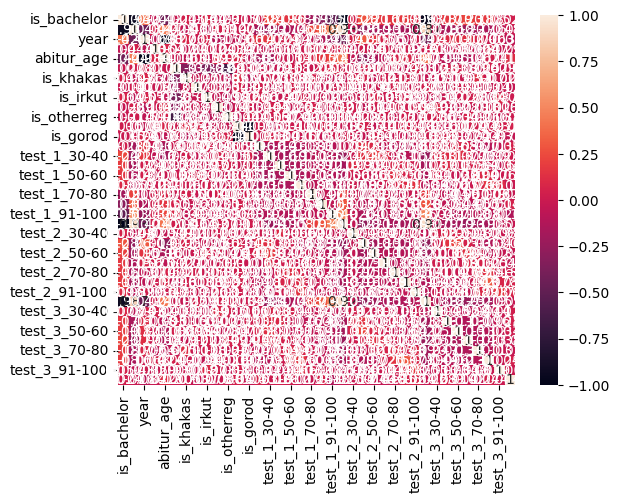

In [49]:
data2.corr()
sns.heatmap(data2.corr(), annot=True);

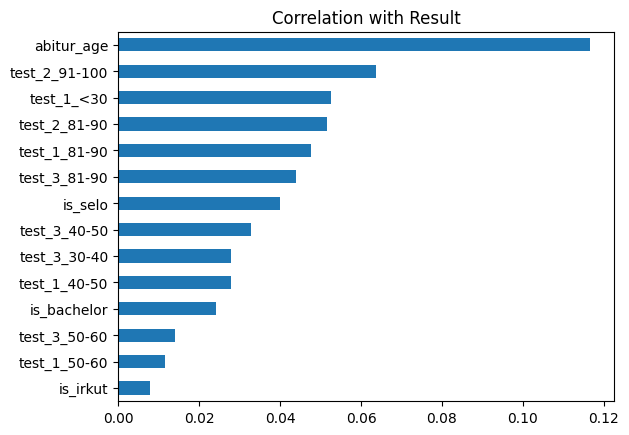

In [50]:
corr = data2.corr()
corr["result"].sort_values()[-15:-1].plot.barh()
plt.title("Correlation with Result")
plt.show()

In [51]:
X = data2.drop(['result'], axis=1)
y = data2['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [52]:
X_test.shape

(582, 37)

In [53]:
y_test.mean()

np.float64(0.7353951890034365)

In [54]:
selector = SelectKBest(score_func = f_classif, k=15)
selector.fit(X_train, y_train)

selector.get_feature_names_out()

array(['year', 'month', 'abitur_age', 'is_tyva', 'test_1_<30',
       'test_1_81-90', 'test_1_91-100', 'test_2_40-50', 'test_2_50-60',
       'test_2_60-70', 'test_2_81-90', 'test_2_91-100', 'test_3_40-50',
       'test_3_60-70', 'test_3_81-90'], dtype=object)

In [55]:
data3 = data2[['year', 'month', 'abitur_age', 'is_tyva', 'test_1_<30',
       'test_1_81-90', 'test_1_91-100', 'test_2_40-50', 'test_2_50-60',
       'test_2_60-70', 'test_2_81-90', 'test_2_91-100', 'test_3_40-50',
       'test_3_60-70', 'test_3_81-90', 'result']]

X = data3.drop(['result'], axis=1)
y = data3['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [56]:
# нормализуйте данные с помощью minmaxsxaler

scaler = preprocessing.MinMaxScaler()
scaler.fit(X_train)                           # fit() только на train данных
X_train_scaled = scaler.transform(X_train)    # fransform() на train данных
X_test_scaled = scaler.transform(X_test)      # fransform() на test данных

print(X_test_scaled[:, 0].mean())

0.8091461802802034


In [57]:
#Обучим логистическую регрессию

Log_reg = linear_model.LogisticRegression(max_iter = 1000, random_state = 42, solver = 'sag')
Log_reg.fit(X_train_scaled, y_train)
y_test_pred = Log_reg.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.62      0.03      0.06       154
           1       0.74      0.99      0.85       428

    accuracy                           0.74       582
   macro avg       0.68      0.51      0.46       582
weighted avg       0.71      0.74      0.64       582



In [58]:
# обучим решающие деревья
#Создаём объект класса DecisionTreeClassifier
dt_clf = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    random_state=42, #генератор случайных чисел
    max_depth=6, #максимальная глубина
)

#Обучаем дерево решений по алгоритму CART без ограничения его длины
dt_clf.fit(X_train_scaled, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)

In [59]:
#Делаем предсказание класса для всего набора данных
y_pred = dt_clf.predict(X)
#Выводим отчёт о метриках классификации
print(metrics.classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.13      0.20       466
           1       0.75      0.95      0.84      1297

    accuracy                           0.73      1763
   macro avg       0.61      0.54      0.52      1763
weighted avg       0.68      0.73      0.67      1763



In [60]:
dt_clf.fit(X_test, y_test)
y_pred = dt_clf.predict(X)
#Выводим отчёт о метриках классификации
print(metrics.classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.18      0.26       466
           1       0.76      0.93      0.83      1297

    accuracy                           0.73      1763
   macro avg       0.61      0.55      0.54      1763
weighted avg       0.68      0.73      0.68      1763



0.78
0.69


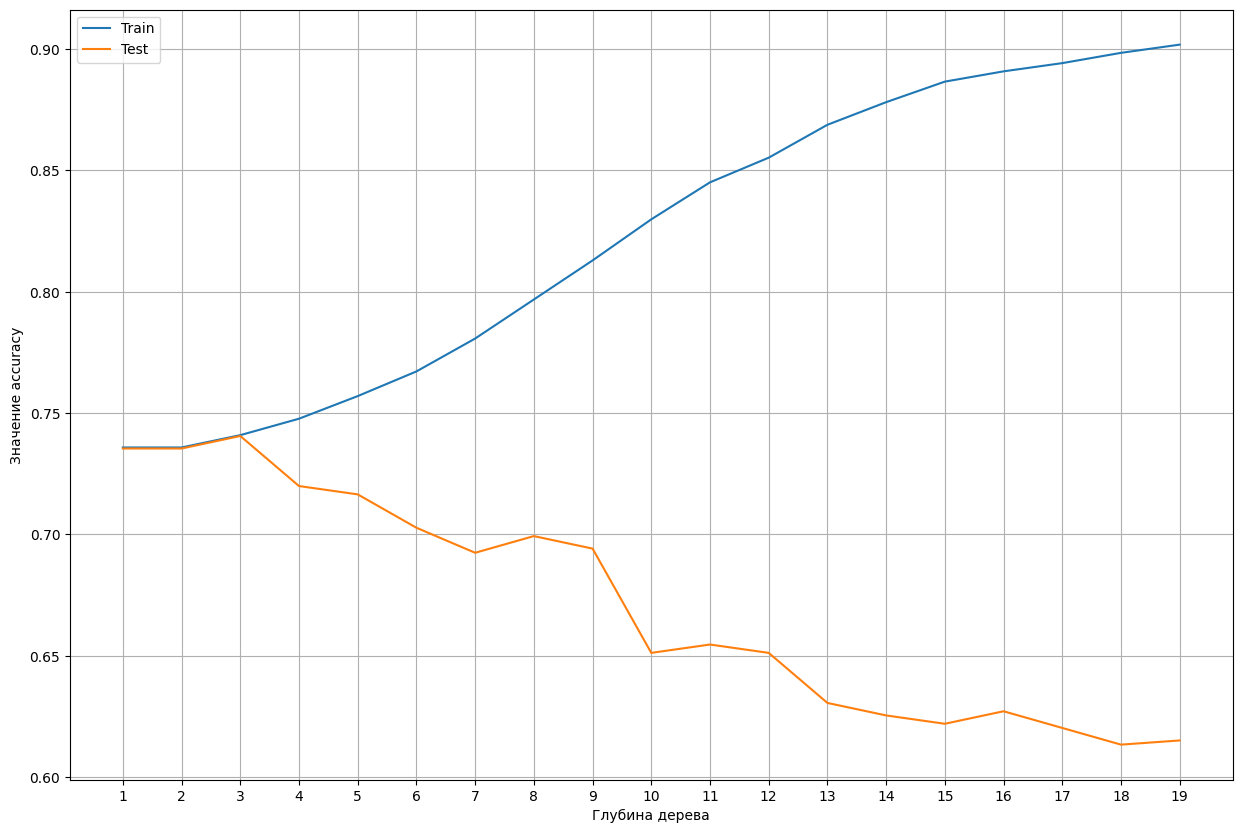

In [61]:
accuracy_test = []
accuracy_train = []
depths = range(1, 20)
for depth in depths:
    dtc = tree.DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=depth)
    dtc.fit(X_train_scaled, y_train)
    accuracy_train.append(metrics.accuracy_score(y_train, dtc.predict(X_train_scaled)))
    accuracy_test.append(metrics.accuracy_score(y_test, dtc.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(15,10))
ax.plot(depths, accuracy_train, label='Train')
ax.plot(depths, accuracy_test, label='Test')
ax.set_xlabel('Глубина дерева')
ax.set_ylabel('Значение accuracy')
ax.xaxis.set_ticks(depths)
ax.grid()
ax.legend()

dtc = tree.DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=7)
dtc.fit(X_train_scaled, y_train)
print(round(metrics.accuracy_score(y_train, dtc.predict(X_train_scaled)), 2))
print(round(metrics.accuracy_score(y_test, dtc.predict(X_test_scaled)), 2))
# 0.84
# 0.82

In [62]:
# подберем оптимальные параметры с помощью gridsearch

param_grid = {'min_samples_split': [2, 5, 7, 10] ,
              'max_depth':[3,5,7]
              }
grid_search =  GridSearchCV(
        estimator=tree.DecisionTreeClassifier(
            criterion='entropy',
            random_state=42
        ),
    param_grid=param_grid,

    n_jobs = -1
)
%time grid_search.fit(X_train_scaled, y_train)
print("accuracy на тестовом наборе: {:.2f}".format(grid_search.score(X_test_scaled, y_test)))
y_test_pred = grid_search.predict(X_test_scaled)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search.best_params_))

CPU times: user 105 ms, sys: 6.5 ms, total: 111 ms
Wall time: 3.42 s
accuracy на тестовом наборе: 0.74
f1_score на тестовом наборе: 0.85
Наилучшие значения гиперпараметров: {'max_depth': 3, 'min_samples_split': 2}


In [63]:
# обучим случайный лес
#Создаём объект класса RandomForestClassifier
rf_clf_2d = ensemble.RandomForestClassifier(
    n_estimators=100, #число деревьев
    criterion='gini', #критерий эффективности
    min_samples_leaf = 2,
    max_depth=3, #максимальная глубина дерева
    random_state=42 #генератор случайных чисел
)
#Обучаем модель
rf_clf_2d.fit(X_train_scaled, y_train)

#Делаем предсказание класса
y_pred = rf_clf_2d.predict(X)
#Выводим отчёт о метриках
print(metrics.classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       466
           1       0.74      1.00      0.85      1297

    accuracy                           0.74      1763
   macro avg       0.37      0.50      0.42      1763
weighted avg       0.54      0.74      0.62      1763



In [64]:
# используем для классификации градиентный бустинг и сравним качество со случайным лесом



# Создаем объект класса градиентный бустинг
gb = ensemble.GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)

# Обучаем модель
gb.fit(X_train_scaled, y_train)

# Формируем предсказание для тестовой выборки
gb_pred  = gb.predict(X_test_scaled)

print(metrics.classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.33      0.17      0.22       154
           1       0.75      0.87      0.80       428

    accuracy                           0.69       582
   macro avg       0.54      0.52      0.51       582
weighted avg       0.63      0.69      0.65       582



In [65]:
# объединим  алгоритмы с помощью стекинга
estimators = [
    ('dt', tree.DecisionTreeClassifier(
        criterion='entropy',
        min_samples_leaf=5,
        max_depth=6,
        random_state=42
        )
    ),
    ('log_reg', linear_model.LogisticRegression(
        solver='sag',
        random_state=42
        )
    ),
    ('gb', ensemble.GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=300,
        min_samples_leaf=5,
        max_depth=5,
        random_state=42
        )
    )
]

stack = ensemble.StackingClassifier(
    estimators,
    final_estimator=linear_model.LogisticRegression(random_state=42)
)
stack.fit(X_train_scaled, y_train)




# Получение предсказаний на тестовой выборке
y_pred = stack.predict(X_test_scaled)

# Вычисление метрики precision
precision = precision_score(y_test, y_pred)

# Вывод результата с округлением до двух знаков после точки-разделителя
print(f'Precision: {precision:.2f}')


Precision: 0.74


In [66]:
# оценим, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга

selector = SelectKBest(f_classif, k=3)
selector.fit(X_train, y_train)

selector.get_feature_names_out()


array(['year', 'abitur_age', 'test_1_91-100'], dtype=object)

4. Вывод

Наибольшую вероятность к заключению договора на обучение демонстируют абитурьенты из Республики Тыва. В то же время, учитывая их малую численность в общем объеме, следует также уделять внимание абитурьентам Красноярского края. Существенной разницы в вероятности заключения договора между городскими и сельскими поселениями не выявлено (согласно регрессионному анализу). Также стоит отметить, что лица более старшего возраста заключают договор на учебу охотнее.


Таким образом, можно определить портрет поступающего в Институт экономики и Управления Красноярского ГАУ: Уроженец Красноярского края и Республики Тыва с баллами по экзамену 1 - минимальный проходной и 81-100, по экзамену 2 -  40-100, по экзамену 3 -  40-90.